# COCO Vir-Head Dataset — Build + Steering Demo

Builds a **COCO-based Vis-Head dataset**: one sample per unambiguous COCO object
(`"Find the <category>."` + the full, unmodified COCO image), with the object's
segmentation kept as *hidden* ground truth and mapped down to the VLM's visual-patch
grid. See `vis_head/coco.py` for the full pipeline (COCO -> ground-truth mask -> VLM
preprocessing -> patch-level occupancy).

This notebook:

1. **Builds the dataset** from raw COCO instance annotations (configurable selection —
   unique-category-only, min area, category whitelist, etc.).
2. **Inspects a sample** — image, hidden mask, and the resulting per-patch occupancy
   heatmap, to sanity-check the COCO -> patch-grid mapping.
3. **Demos vir-head steering** on a COCO sample, exactly like
   `interactive_steering_qwen2vl.ipynb`'s region-steering part, but using the COCO
   ground-truth object (not a hand-drawn ROI) as the steering target.

**Prerequisites**
- COCO `instances_{split}.json` + images under `VIR_COCO_ROOT`
  (default `/mnt/abka03/raw_data_download/mscoco2024`).
- A GPU for the steering demo (dataset building itself is CPU-only).
- Vir-head rankings from `01_discover_vis_heads.py` /
  `compare_base_vs_instruct_vis_heads.ipynb`.
- Run from the repository root so `vis_head` imports resolve.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "vis_head").exists():
    raise RuntimeError("Run this notebook from the repository root (vis-head/).")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

from vis_head.common import DEFAULT_MODEL_ID, DEFAULT_SEED
from vis_head.coco import (
    DEFAULT_COCO_OUTPUT_DIR,
    DEFAULT_COCO_ROOT,
    DEFAULT_COCO_SPLIT,
    SelectionConfig,
    vis_head_score_from_patch_mask,
    ground_truth_record,
    load_coco_index,
    load_coco_vis_head_dataset,
    mask_to_patch_occupancy,
    sample_metadata_record,
    segmentation_to_mask,
    select_target_objects,
    write_jsonl,
)
from vis_head.vir import load_head_ranking
from vis_head.modeling import (
    decode_generated_text,
    find_image_token_range,
    load_model_and_processor,
    model_dims,
    prepare_inputs,
    run_generation,
)
from vis_head.plots import add_overlay_colorbar, draw_attention_overlay
from vis_head.regions import bbox_to_token_positions, get_merged_grid_shape, reshape_token_values
from vis_head.steering import (
    compute_step_value_weighted_token_attention,
    group_heads_by_layer,
    intervention_positions,
    make_static_attention_mask_hook,
    register_attention_trackers,
    register_mask_hooks,
    register_prefill_value_norm_trackers,
    remove_handles,
)


## Part 1 — Build the COCO vir dataset

`SelectionConfig` is the dataset-selection flag surface (also reused by
`compare_base_vs_instruct_vis_heads.ipynb` and `interactive_steering_qwen2vl.ipynb`
via `DATASET_SOURCE = "coco"`):

- `unique_category_only` — keep only objects whose category appears exactly once in
  the image, so `"Find the dog."` is unambiguous (default `True`).
- `min_area` / `min_bbox_side` — drop tiny/near-invisible objects.
- `category_names` — restrict to a category whitelist (`None` = all 80 COCO classes).
- `max_per_category`, `max_samples`, `seed` — dataset size and balance.


In [2]:
COCO_ROOT = DEFAULT_COCO_ROOT
COCO_SPLIT = DEFAULT_COCO_SPLIT          # "train2014" or "val2014"
OUTPUT_DIR = DEFAULT_COCO_OUTPUT_DIR
MODEL_ID = DEFAULT_MODEL_ID

SELECTION = SelectionConfig(
    unique_category_only=True,
    min_area=800.0,
    category_names=None,       # e.g. ["dog", "car", "person", "bicycle"]
    max_per_category=20,
    max_samples=300,
    seed=DEFAULT_SEED,
)

print(f"COCO root : {COCO_ROOT}  [{COCO_SPLIT}]")
print(f"Output    : {OUTPUT_DIR}")
print(SELECTION)


COCO root : /mnt/abka03/raw_data_download/mscoco2024  [val2014]
Output    : /mnt/abka03/Projects/vis-head/data/coco_vis_head
SelectionConfig(unique_category_only=True, require_single_polygon=False, exclude_iscrowd=True, min_area=800.0, min_bbox_side=8.0, category_names=None, max_per_category=20, max_samples=300, seed=42)


In [3]:
print("Indexing COCO annotations...")
coco_index = load_coco_index(coco_root=COCO_ROOT, split=COCO_SPLIT)
targets = select_target_objects(coco_index, SELECTION)
print(f"Selected {len(targets)} unambiguous target objects "
      f"across {len(coco_index.images_by_id)} images.")

from collections import Counter
category_counts = Counter(t.category_name for t in targets)
print("Top categories:", category_counts.most_common(10))


Indexing COCO annotations...
Selected 300 unambiguous target objects across 40504 images.
Top categories: [('person', 20), ('dining table', 19), ('truck', 11), ('cat', 11), ('laptop', 10), ('tie', 10), ('bed', 10), ('chair', 8), ('dog', 8), ('tv', 8)]


### Ground-truth mask -> VLM patch grid

We only need the VLM's *image processor* (not the full model) to get the real
`image_grid_thw` for each COCO image — this determines the patch grid the
segmentation mask is downsampled onto (step 5-6 of the pipeline: same spatial
preprocessing applied to image and mask, then per-patch occupancy).

In [4]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)
spatial_merge = getattr(image_processor, "merge_size", 2)

metadata_records, ground_truth_records = [], []
for target in tqdm(targets, desc="Building samples"):
    image_path = Path(target.image_path)
    if not image_path.exists():
        continue
    with Image.open(image_path) as img:
        image = img.convert("RGB")

    processed = image_processor(images=image, return_tensors="pt")
    grid_shape = get_merged_grid_shape(processed["image_grid_thw"], spatial_merge)

    mask = segmentation_to_mask(target.segmentation, target.image_height, target.image_width)
    patch_mask = mask_to_patch_occupancy(mask, grid_shape)

    metadata_records.append(sample_metadata_record(target))
    ground_truth_records.append(ground_truth_record(target, grid_shape, patch_mask))

write_jsonl(OUTPUT_DIR / "metadata.jsonl", metadata_records)
write_jsonl(OUTPUT_DIR / "ground_truth.jsonl", ground_truth_records)
print(f"Wrote {len(metadata_records)} samples to {OUTPUT_DIR}")
print("Model input for sample 0:", metadata_records[0]["instruction"], "+ full image (no bbox/segmentation given).")


Building samples:   0%|          | 0/300 [00:00<?, ?it/s]

Wrote 300 samples to /mnt/abka03/Projects/vis-head/data/coco_vis_head
Model input for sample 0: Find the person. + full image (no bbox/segmentation given).


## Part 2 — Inspect one sample

Sanity-check the COCO object -> segmentation -> patch-occupancy mapping before using
it as ground truth. The model only ever sees the left panel (image) and the
instruction text — the mask/heatmap on the right is hidden ground truth.

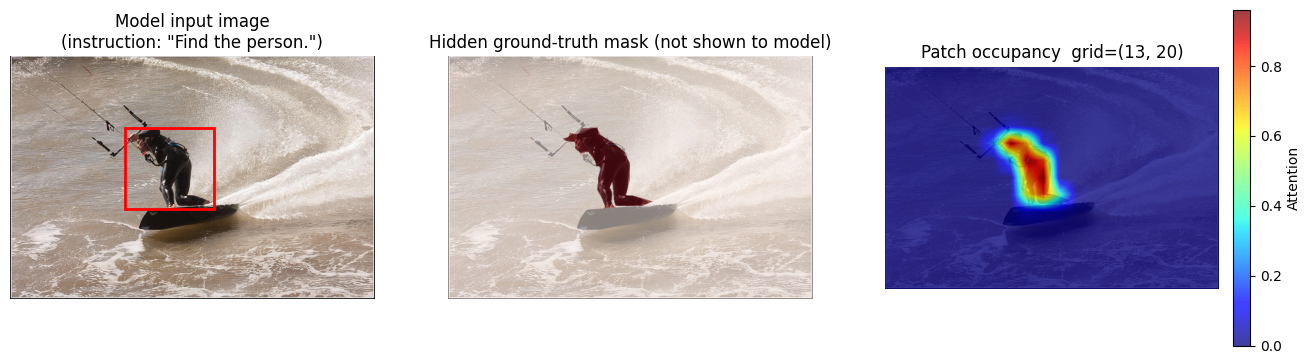

sample_id=0  category=person  annotation_id=2204961  patches with occupancy>0: 18


In [5]:
dataset = load_coco_vis_head_dataset(OUTPUT_DIR)
SAMPLE_IDX = 0
meta, gt = dataset[SAMPLE_IDX]

image = Image.open(meta["image_path"]).convert("RGB")
mask = segmentation_to_mask(gt["segmentation"], image.size[1], image.size[0])
patch_mask = np.array(gt["patch_mask"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(image)
x, y, w, h = gt["bbox"]
axes[0].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none"))
axes[0].set_title(f'Model input image\n(instruction: "{meta["instruction"]}")')
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(mask, cmap="Reds", alpha=0.5)
axes[1].set_title("Hidden ground-truth mask (not shown to model)")
axes[1].axis("off")

draw_attention_overlay(axes[2], image=image, heatmap=patch_mask,
                       title=f'Patch occupancy  grid={tuple(gt["patch_grid"])}')
add_overlay_colorbar(fig, axes[2])
plt.show()
print(f"sample_id={meta['sample_id']}  category={meta['category_name']}  "
      f"annotation_id={meta['annotation_id']}  patches with occupancy>0: {(patch_mask > 0).sum()}")


## Part 3 — Vir steering demo on a COCO sample

Same intervention as `interactive_steering_qwen2vl.ipynb` Part 3 (a pre-softmax
attention bias on the vis heads: **+bias** on the target object's image tokens,
**-bias** elsewhere), but the target region now comes straight from the COCO
ground truth instead of a hand-drawn ROI.

In [7]:
DEVICE = "cuda:0"
VIS_HEAD_RANKING_PATH = REPO_ROOT / "logs" / "vis_head_discovery" / "vis_head_ranking.json"
TOP_K_VIR = 100
MAX_NEW_TOKENS = 40

model, processor = load_model_and_processor(model_id=MODEL_ID, device=DEVICE)
n_layers, n_query_heads, spatial_merge = model_dims(model)

vis_head = load_head_ranking(VIS_HEAD_RANKING_PATH, top_k=TOP_K_VIR)
vir_by_layer = group_heads_by_layer(vis_head)
print(f"Loaded {len(vis_head)} vis heads across {len(vir_by_layer)} layers "
      f"(model: {n_layers} layers x {n_query_heads} heads)")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loaded 100 vis heads across 16 layers (model: 36 layers x 32 heads)


Instruction        : Find the person.
Baseline           : ```json
[
	{"bbox_2d": [317, 298, 550, 629], "label": "person"}
]
```
Steered to object  : ```json
{
    "object": "person",
    "description": "A person wearing a black wetsuit and holding a harness, standing in a swimming pool with a blue and black uniform


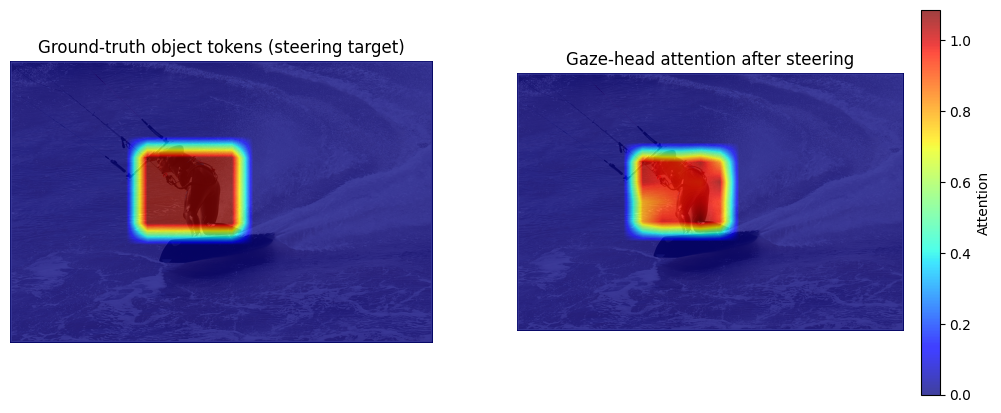

In [8]:
def steer_sample(sample_idx: int, intervention: str = "boost_suppress", max_new_tokens: int = MAX_NEW_TOKENS):
    meta, gt = dataset[sample_idx]
    image = Image.open(meta["image_path"]).convert("RGB")
    prompt = meta["instruction"]  # the only text the model ever sees; no coordinates.

    inputs = prepare_inputs(processor, image, prompt, DEVICE)
    img_start, img_end = find_image_token_range(inputs, processor)
    grid_shape = get_merged_grid_shape(inputs["image_grid_thw"], spatial_merge)

    # Ground-truth bbox -> image-token positions (same helper used for hand-drawn ROIs).
    x, y, w, h = gt["bbox"]
    bbox_xyxy = (x, y, x + w, y + h)
    cell_mask, target_positions = bbox_to_token_positions(bbox_xyxy, grid_shape, image.size, img_start)
    other_positions = [p for p in range(img_start, img_end) if p not in set(target_positions)]

    prompt_length = int(inputs["input_ids"].shape[1])
    suppress_positions, boost_positions, pad_with_suppress = intervention_positions(
        mode=intervention,
        target_positions=target_positions,
        other_image_positions=other_positions,
        img_start=img_start,
        img_end=img_end,
        prompt_length=prompt_length,
    )
    hook_by_layer = {
        layer_idx: make_static_attention_mask_hook(
            head_indices=heads,
            suppress_positions=suppress_positions,
            boost_positions=boost_positions,
            n_query_heads=n_query_heads,
            device=DEVICE,
            decode_only=False,
            pad_with_suppress=pad_with_suppress,
        )
        for layer_idx, heads in vir_by_layer.items()
    }

    baseline_sequences = run_generation(model=model, inputs=inputs, max_new_tokens=max_new_tokens)
    baseline_text = decode_generated_text(processor, baseline_sequences, prompt_length)

    steer_inputs = prepare_inputs(processor, image, prompt, DEVICE)
    records, value_norms = [], {}
    tracker_handles = register_attention_trackers(model, sorted(vir_by_layer.keys()), records)
    value_handles = register_prefill_value_norm_trackers(
        model=model, layers=sorted(vir_by_layer.keys()),
        img_start=img_start, img_end=img_end, storage=value_norms,
    )
    mask_handles = register_mask_hooks(model, hook_by_layer)
    try:
        steered_sequences = run_generation(model=model, inputs=steer_inputs, max_new_tokens=max_new_tokens)
    finally:
        remove_handles(mask_handles)
        remove_handles(tracker_handles)
        remove_handles(value_handles)
    steered_text = decode_generated_text(processor, steered_sequences, prompt_length)

    step_attn = compute_step_value_weighted_token_attention(
        records=records, heads_by_layer=vir_by_layer,
        img_start=img_start, img_end=img_end, value_norms_by_layer=value_norms,
    )
    heatmap = (
        reshape_token_values(step_attn.mean(axis=0), grid_shape)
        if step_attn.size > 0 else np.zeros(grid_shape[1:])
    )

    return {
        "meta": meta, "gt": gt, "image": image, "cell_mask": cell_mask,
        "baseline_text": baseline_text, "steered_text": steered_text, "heatmap": heatmap,
    }


result = steer_sample(SAMPLE_IDX)
print(f'Instruction        : {result["meta"]["instruction"]}')
print(f'Baseline           : {result["baseline_text"]}')
print(f'Steered to object  : {result["steered_text"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_attention_overlay(axes[0], image=result["image"], heatmap=result["cell_mask"].astype(np.float64),
                       title="Ground-truth object tokens (steering target)")
draw_attention_overlay(axes[1], image=result["image"], heatmap=result["heatmap"],
                       title="Vir-head attention after steering")
add_overlay_colorbar(fig, axes[1])
plt.show()


### Browse samples interactively

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None
    print("ipywidgets unavailable — call steer_sample(idx) directly instead, e.g. steer_sample(3)")

if widgets is not None:
    idx_slider = widgets.IntSlider(value=0, min=0, max=len(dataset) - 1, description="sample_id:")
    steer_button = widgets.Button(description="Steer", button_style="primary")
    output_area = widgets.Output()

    def _on_steer(_):
        with output_area:
            output_area.clear_output()
            print("Generating...")
            r = steer_sample(idx_slider.value)
            output_area.clear_output()
            print(f'[{r["meta"]["category_name"]}] {r["meta"]["instruction"]}')
            print(f'Baseline : {r["baseline_text"]}')
            print(f'Steered  : {r["steered_text"]}')
            fig, ax = plt.subplots(figsize=(6, 5))
            draw_attention_overlay(ax, image=r["image"], heatmap=r["heatmap"], title="Steered attention")
            plt.show()

    steer_button.on_click(_on_steer)
    display(widgets.VBox([idx_slider, steer_button, output_area]))


## Part 4 — (optional) Score vis heads directly against COCO ground truth

`vis_head_score_from_patch_mask` weights each head's raw image-token attention by the
COCO patch-occupancy mask instead of a one-hot panel id — a drop-in alternative to
`vis_head.vir.aggregate_region_attention` for ranking heads on natural images
rather than comic panels.

In [10]:
from vis_head.vir import collect_last_query_attentions

n_score_samples = min(20, len(dataset))
score_sum = np.zeros((n_layers, n_query_heads), dtype=np.float64)
for i in tqdm(range(n_score_samples), desc="Scoring vis heads on COCO"):
    meta, gt = dataset[i]
    image = Image.open(meta["image_path"]).convert("RGB")
    inputs = prepare_inputs(processor, image, meta["instruction"], DEVICE)
    img_start, img_end = find_image_token_range(inputs, processor)
    attn_at_query = collect_last_query_attentions(model, inputs)
    score_sum += vis_head_score_from_patch_mask(attn_at_query, img_start, img_end, gt["patch_mask_flat"])

coco_vis_head_scores = score_sum / n_score_samples
top = np.dstack(np.unravel_index(np.argsort(-coco_vis_head_scores.ravel()), coco_vis_head_scores.shape))[0][:10]
print("Top COCO-scored heads (layer, head, score):")
for layer_idx, head_idx in top:
    print(f"  L{layer_idx:02d} H{head_idx:02d}  score={coco_vis_head_scores[layer_idx, head_idx]:.4f}")


Scoring vis heads on COCO:   0%|          | 0/20 [00:00<?, ?it/s]

Top COCO-scored heads (layer, head, score):
  L20 H15  score=0.1535
  L00 H27  score=0.1358
  L00 H29  score=0.1288
  L21 H11  score=0.1204
  L00 H05  score=0.1191
  L00 H08  score=0.1131
  L05 H29  score=0.1109
  L12 H18  score=0.0884
  L24 H29  score=0.0854
  L23 H28  score=0.0779
